In [8]:
import pandas as pd
import numpy as np

# Create a dummy DataFrame for demonstration
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=100, freq='D')
page_views = np.random.randint(1000, 5000, size=100) + np.sin(np.linspace(0, 20, 100)) * 1000

dummy_data = pd.DataFrame({'Date': dates, 'Page_Views': page_views.astype(int)})
dummy_data.to_csv('website_traffic.csv', index=False)

print("Created 'website_traffic.csv' with dummy data.")

Created 'website_traffic.csv' with dummy data.


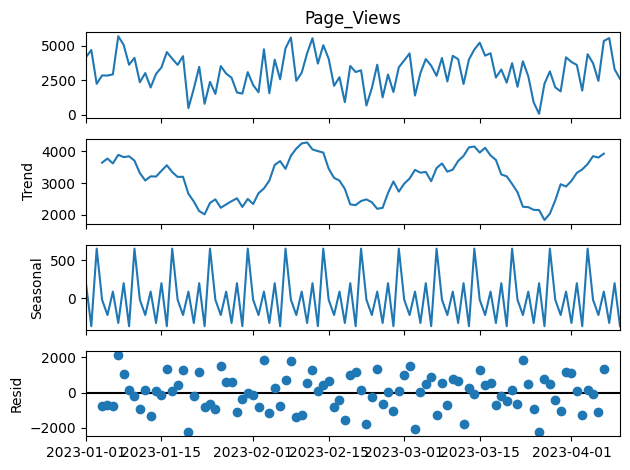

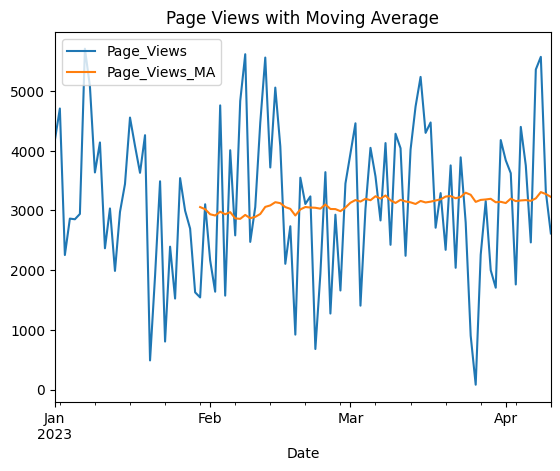

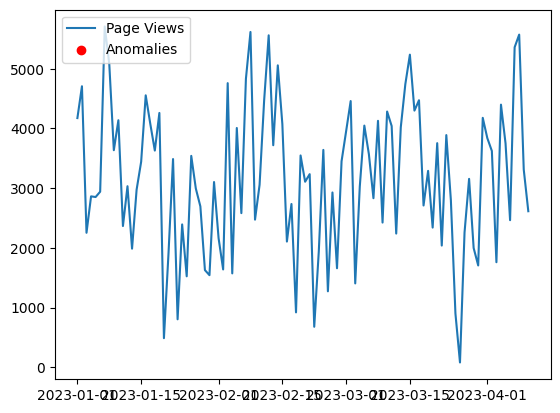

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset
data = pd.read_csv('website_traffic.csv', parse_dates=['Date'], index_col='Date')

# Time Series Decomposition
decomposition = seasonal_decompose(data['Page_Views'], model='additive')
decomposition.plot()

plt.show()

# Moving Average
data['Page_Views_MA'] = data['Page_Views'].rolling(window=30).mean()
data[['Page_Views', 'Page_Views_MA']].plot()
plt.title('Page Views with Moving Average')
plt.show()

# Anomaly Detection
data['Page_Views_Z'] = (data['Page_Views'] - data['Page_Views'].mean()) / data['Page_Views'].std()
anomalies = data[data['Page_Views_Z'].abs() > 3]
plt.plot(data.index, data['Page_Views'], label='Page Views')
plt.scatter(anomalies.index, anomalies['Page_Views'], color='red', label='Anomalies')
plt.legend()
plt.show()